In [1]:
# Please run this cell for custom formating of notebook cells
from IPython.core.display import HTML
css = open('style-table.css').read() + open('style-notebook.css').read()
HTML('<style>{}</style>'.format(css))

This notebook contains code and documentation for a COVID 19 predictive model using dataset of cases of Covid-19 in the town of  Hocus Pocus.
For the sake of reproducibility, this kernel was writen using the following environmental set up

Python 3.5.2
Cython 0.24.1
Numpy 1.14.2
Pandas 0.20.3
Scikit Learn 0.14.1
Scipy 1.0.1
Seaborn 0.8.1

### Table Of Contents

Introduction
Loading packages
Loading datasets
Data Exploration/Analysis
Data cleaning and preprocessing
Machine Learning algorithms brawl (Base and Ensemble models)
Algorithm tuning
Ensembles
Saving the model
Making submissions

In [2]:
# here's several helpful packages to load in 

import numpy as np
import pandas as pd
from datetime import datetime
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold,GridSearchCV, cross_val_score
from sklearn.metrics import classification_report ,confusion_matrix ,accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes  import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier,ExtraTreesClassifier
import sys
from IPython.display import display

### Load the dataset

In [3]:
# Function that returns the size of an object in MB
def size(obj):
    return "{0:.2f} MB".format(sys.getsizeof(obj) / (1000 * 1000))

In [4]:
COVID = pd.read_excel("data/COVID19.xlsx", index_col=None,  na_values=["MISSINGVAL", 'NA','?'])

In [5]:
print('covid -- dimensions: {0};   size: {1}'.format(COVID.shape, size(COVID)))

covid -- dimensions: (109927, 47);   size: 184.09 MB


In [6]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 100)
pd.set_option('display.precision', 3)

### Data Exploration/Analysis

In [7]:
# Head
COVID.head(3)

,Sex,Birth Year,Chest pain,Chills or sweats,Confused or disoriented,Cough,Diarrhea,Difficulty breathing or Dyspnea,Digested blood or coffee grounds in vomit,Pain behind eyes or Sensitivity to light,...,Cough with sputum,Cough with heamoptysis,Enlarged lymph nodes,Wheezing,Skin ulcers,Inability to walk,Indrawing of chest wall,Other complications,Specify other complications,Result
0,MALE,1967.0,NO,NO,NO,NO,NO,NO,NaN,NaN,...,NO,NO,NO,NO,NO,NO,NO,1.0,NaN,PENDING
1,MALE,1976.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MALE,1988.0,NO,NO,NO,NO,NO,NO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE


In [8]:
# some info please
print(COVID.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109927 entries, 0 to 109926
Data columns (total 47 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Sex                                        107228 non-null  object 
 1   Birth Year                                 94963 non-null   float64
 2   Chest pain                                 42120 non-null   object 
 3   Chills or sweats                           24857 non-null   object 
 4   Confused or disoriented                    23127 non-null   object 
 5   Cough                                      42218 non-null   object 
 6   Diarrhea                                   42092 non-null   object 
 7   Difficulty breathing or Dyspnea            24940 non-null   object 
 8   Digested blood or coffee grounds in vomit  1397 non-null    object 
 9   Pain behind eyes or Sensitivity to light   1405 non-null    object 
 10  Bleeding

In [9]:
# Checking for variables with missing values in descending order
COVID.isnull().sum().sort_values(ascending=False)

Specify other complications                  109922
Bleeding from the eyes                       108530
Bleeding of the gums                         108530
Digested blood or coffee grounds in vomit    108530
Fluid in the lung cavity                     108523
Pain behind eyes or Sensitivity to light     108522
Pharyngeal exudate                           106928
Malaise                                      106921
Conjunctivitis                                91274
Other complications                           89175
Indrawing of chest wall                       88904
Skin ulcers                                   88904
Wheezing                                      88902
Bleeding or bruising                          88897
Maculopapular rash                            88895
Inability to walk                             88895
Enlarged lymph nodes                          88884
Cough with heamoptysis                        87747
Cough with sputum                             87746
Rapid breath

In [10]:
# Checking and visualizing target class distribution
COVID.Result.value_counts(normalize=True)

Result
NEGATIVE         6.546e-01
PENDING          2.879e-01
POSITIVE         5.741e-02
INDETERMINATE    5.304e-05
Name: proportion, dtype: float64

<Axes: xlabel='Result'>

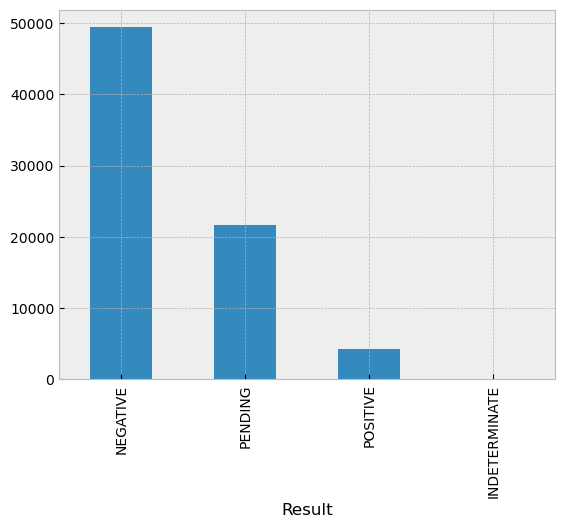

In [11]:
import matplotlib.pyplot as plt
plt.style.use('bmh')
%matplotlib inline
COVID.Result.value_counts().plot(kind='bar')

### Data Preprocessing and Cleaning

In [12]:
#Converting to Birthdate to age
current_year = datetime.today().year
COVID['Age'] = current_year - COVID['Birth Year']

In [13]:
#converting Binary variables to 0,1 values

mapping = {
    'YES': 1, 'NO': 0
}
COVID.replace(mapping, inplace=True)


C:\Users\George\AppData\Local\Temp\ipykernel_7536\1346478757.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  COVID.replace(mapping, inplace=True)


In [14]:
#Dropping noninformative variables

COVID.drop(columns=['Specify other complications','Birth Year'], inplace=True)

In [15]:
COVID.drop(columns=['Bleeding from the eyes','Digested blood or coffee grounds in vomit'], inplace=True)

In [16]:
#Dropping Result rows with INDETERMINATE Values
COVID = COVID[COVID['Result'] !='INDETERMINATE']

In [17]:
#Dropping NaN values in the Result column
COVID.dropna(subset=['Result'], inplace=True)

In [18]:
#converting Binary variables to 0,1 values

mapping = {
    'FEMALE': 1, 'MALE': 0
}
COVID['Sex'] = COVID['Sex'].map(mapping)

In [19]:
COVID.head(20)

,Sex,Chest pain,Chills or sweats,Confused or disoriented,Cough,Diarrhea,Difficulty breathing or Dyspnea,Pain behind eyes or Sensitivity to light,Fatigue or general weakness,Fever,...,Cough with sputum,Cough with heamoptysis,Enlarged lymph nodes,Wheezing,Skin ulcers,Inability to walk,Indrawing of chest wall,Other complications,Result,Age
0,0.0,0,0,0,0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,1.0,PENDING,58.0
2,0.0,0,0,0,0,0,0,NaN,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,37.0
4,1.0,0,0,0,1,0,1,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,47.0
5,0.0,0,0,0,1,0,0,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,30.0
6,0.0,0,0,0,0,0,0,NaN,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,58.0
7,0.0,0,0,0,0,0,0,NaN,0,0,...,0,0,0,0,0,0,0,1.0,NEGATIVE,10.0
8,0.0,0,0,0,0,0,0,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,34.0
9,0.0,0,0,0,1,0,0,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,27.0
10,0.0,0,0,0,0,0,0,NaN,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,52.0
11,0.0,0,0,0,0,0,0,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NEGATIVE,56.0


In [20]:
# Splitting dataset based on RESULT column values
Covid_train = COVID[COVID['Result'] != 'PENDING']
Covid_pending =  COVID[COVID['Result'] == 'PENDING']
Covid_test =  Covid_pending.drop('Result', axis=1)

### Label Ecoding

In [21]:
mapping = {
    'POSITIVE': 1, 'NEGATIVE': 0
}
Covid_train['Result'] = Covid_train['Result'].map(mapping)

C:\Users\George\AppData\Local\Temp\ipykernel_7536\152713293.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Covid_train['Result'] = Covid_train['Result'].map(mapping)


In [22]:
Covid_train.shape

(53701, 44)

In [23]:
Covid_test.shape

(21711, 43)

In [24]:
#seperating the target class from the rest of the features
covid_train_nr = Covid_train.drop('Result', axis=1)
Results = Covid_train['Result']


In [25]:
covid_train_nr.replace("UNKNOWN", np.nan, inplace=True)
covid_train_nr.fillna(covid_train_nr.mode().iloc[0], inplace=True)

C:\Users\George\AppData\Local\Temp\ipykernel_7536\616343790.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  covid_train_nr.replace("UNKNOWN", np.nan, inplace=True)


### Spliting into train (80%) and validation set(20%)

In [26]:
X = covid_train_nr.values
y = Results.values
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=.20, random_state=0)

### Handling class imbalance

In [27]:
COVID.Result.value_counts(normalize=True)

Result
NEGATIVE    0.655
PENDING     0.288
POSITIVE    0.057
Name: proportion, dtype: float64

In [28]:
# Handling Target class imbalance by combination of over-sampling and under-sampling using the imbalance-learn SMOTEENN module
from collections import Counter
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=0)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)
print(sorted(Counter(y_resampled).items()))

[(0, 33632), (1, 3836)]


### Building pipelines for scaling and model instantiation

In [29]:
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()),('LR', LogisticRegression())])))
pipelines.append(('ScaledSVM', Pipeline([('scaler', StandardScaler()),('SVM', SVC())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN', KNeighborsClassifier())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART', DecisionTreeClassifier())])))
pipelines.append(('ScaledNB', Pipeline([('Scaler', StandardScaler()),('NB', GaussianNB())])))

### Evaluate Algorithms

In [30]:
num_folds= 10
seed = 0
scoring = 'accuracy'

In [31]:
results = []
names = []
for name, model in pipelines:
    kfold= KFold(n_splits=num_folds,shuffle=True, random_state=0)
    cv_results = cross_val_score(model,X_resampled, y_resampled, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print('{0}:{1:.4f}({2:.4f})'.format(name, cv_results.mean(), cv_results.std()))

ScaledLR:0.9592(0.0029)
ScaledSVM:0.9789(0.0019)
ScaledKNN:0.9920(0.0021)
ScaledCART:0.9961(0.0012)
ScaledNB:0.9510(0.0038)


[Text(1, 0, 'ScaledLR'),
 Text(2, 0, 'ScaledSVM'),
 Text(3, 0, 'ScaledKNN'),
 Text(4, 0, 'ScaledCART'),
 Text(5, 0, 'ScaledNB')]

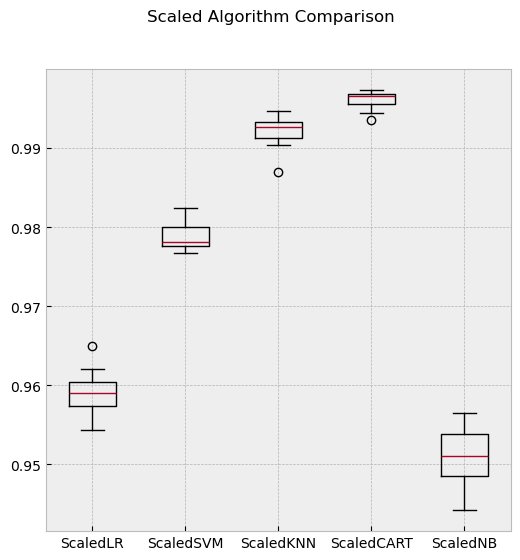

In [32]:
# visualization of individual performance
fig = plt.figure(figsize=(6,6))
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

### Algorithm Tuning

#### Hyper parameter tuning of logistic regression model

In [33]:
from sklearn.pipeline import make_pipeline

c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
param_grid = {'logisticregression__C': c_values}
pipe = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', max_iter=5000))
kfold = KFold(n_splits=num_folds,shuffle=True, random_state=0)
gridLR = GridSearchCV(pipe,param_grid=param_grid,cv=kfold, scoring=scoring)
grid_resultsLR = gridLR.fit(X_resampled, y_resampled)
print('Best:{0:.4f} using {1}'.format(grid_resultsLR.best_score_, grid_resultsLR.best_params_))

Best:0.9592 using {'logisticregression__C': 1}


In [34]:
from sklearn.metrics import roc_auc_score
scaler = StandardScaler().fit(X_resampled)
rescaledX = scaler.transform(X_resampled)
logreg_model = LogisticRegression(C=1)
logreg_model.fit(rescaledX, y_resampled)
rescaledValidationX = scaler.transform(X_validation)
predictions =logreg_model.predict(rescaledValidationX)
print('Accuracy:',accuracy_score(y_validation, predictions))
print()
print('Confusion matrix:\n', confusion_matrix(y_validation, predictions))
print()
print('Classification Report:\n', classification_report(y_validation,predictions))
print()
print('ROC_AUC:', roc_auc_score(y_validation, predictions) )

Accuracy: 0.907085001396518

Confusion matrix:
 [[9656  200]
 [ 798   87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      9856
           1       0.30      0.10      0.15       885

    accuracy                           0.91     10741
   macro avg       0.61      0.54      0.55     10741
weighted avg       0.87      0.91      0.88     10741


ROC_AUC: 0.5390064384767775


### Ensembles

In [35]:
ensembles = []
ensembles.append(('AB', AdaBoostClassifier()))
ensembles.append(('GBM', GradientBoostingClassifier()))
ensembles.append(('RF', RandomForestClassifier()))
ensembles.append(('ET', ExtraTreesClassifier()))
results =[]
names =[]
for name, model in ensembles:
    kfold =KFold(n_splits=num_folds,shuffle=True, random_state=0)
    cv_results = cross_val_score(model, X_resampled, y_resampled, cv=kfold, scoring='accuracy')
    names.append(name)
    results.append(cv_results)
    print('{0}:{1:.4f}({2:.4f})'.format(name, cv_results.mean(), cv_results.std()))

C:\Users\George\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\George\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\George\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\George\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users

AB:0.9758(0.0020)
GBM:0.9883(0.0015)
RF:0.9970(0.0011)
ET:0.9971(0.0012)


[Text(1, 0, 'AB'), Text(2, 0, 'GBM'), Text(3, 0, 'RF'), Text(4, 0, 'ET')]

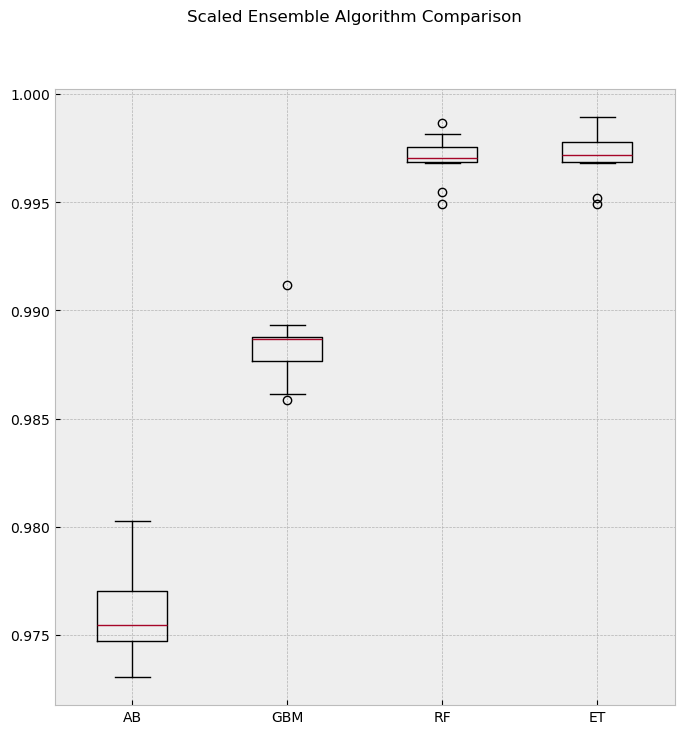

In [36]:
fig = plt.figure(figsize=(8,8))
fig.suptitle('Scaled Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

#### Parameter tuning for RandomForestClassifier

In [37]:
scaler = StandardScaler().fit(X_resampled)
rescaledX = scaler.transform(X_resampled)
param_grid = dict(n_estimators=np.array([50,100,150,200,250,300,350,400]))
RFmodel = RandomForestClassifier(random_state=seed)
kfold = KFold(n_splits=num_folds,shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=RFmodel, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, y_resampled)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.997224 using {'n_estimators': 150}
0.997118 (0.001066) with: {'n_estimators': 50}
0.997118 (0.001162) with: {'n_estimators': 100}
0.997224 (0.001177) with: {'n_estimators': 150}
0.997144 (0.001291) with: {'n_estimators': 200}
0.997144 (0.001241) with: {'n_estimators': 250}
0.997144 (0.001200) with: {'n_estimators': 300}
0.997171 (0.001207) with: {'n_estimators': 350}
0.997171 (0.001207) with: {'n_estimators': 400}


#### Validation performance of RandomForestClassifier

In [38]:
scaler = StandardScaler().fit(X_resampled)
rescaledX = scaler.transform(X_resampled)
RFmodel = RandomForestClassifier(n_estimators=150)
RFmodel.fit(rescaledX, y_resampled)
rescaledValidationX = scaler.transform(X_validation)
predictions = RFmodel.predict(rescaledValidationX)
print('Accuracy:',accuracy_score(y_validation, predictions))
print()
print('Confusion matrix:\n', confusion_matrix(y_validation, predictions))
print()
print('Classification Report:\n', classification_report(y_validation,predictions))
print('ROC_AUC:', roc_auc_score(y_validation, predictions) )

Accuracy: 0.9068056977935015

Confusion matrix:
 [[9648  208]
 [ 793   92]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      9856
           1       0.31      0.10      0.16       885

    accuracy                           0.91     10741
   macro avg       0.62      0.54      0.55     10741
weighted avg       0.87      0.91      0.89     10741

ROC_AUC: 0.5414254530779955


#### Voting Ensemble

In [39]:
from sklearn.ensemble import VotingClassifier
scaler = StandardScaler().fit(X_resampled)
rescaledX = scaler.transform(X_resampled)
ensemble = VotingClassifier(estimators=[('lr', logreg_model), ('rfm', RFmodel)],voting='soft')
ensemble.fit(rescaledX, y_resampled)
rescaledValidationX = scaler.transform(X_validation)
predictions = ensemble.predict(rescaledValidationX)
print('Accuracy:',accuracy_score(y_validation, predictions))
print()
print('Confusion matrix:\n', confusion_matrix(y_validation, predictions))
print()
print('Classification Report:\n', classification_report(y_validation,predictions))
print('ROC_AUC:', roc_auc_score(y_validation, predictions) )

Accuracy: 0.9075505074015455

Confusion matrix:
 [[9654  202]
 [ 791   94]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      9856
           1       0.32      0.11      0.16       885

    accuracy                           0.91     10741
   macro avg       0.62      0.54      0.56     10741
weighted avg       0.87      0.91      0.89     10741

ROC_AUC: 0.5428597796977034


### Saving The Model

#### Save Model Using joblib

In [40]:
import joblib
# save the model to disk
filename = 'models/covid_model.pkl'
joblib.dump(logreg_model, filename)

['models/covid_model.pkl']